<div style="background: linear-gradient(135deg,#1a2a6c,#16222a); padding:30px; border-radius:15px; color:white; font-family:Arial;">

<h1 style="text-align:center; color:#4FC3F7;">🧠 Predicting Creativity from Text Using NLP and RAG</h1>

<hr style="border:1px solid #4FC3F7;">

<h2 style="color:#FFD54F;"> Project Goal</h2>

<p style="color:#FF6B6B; font-size:16px; line-height:1.6;">
The goal of this project is to investigate whether 
<strong>artificial intelligence can detect creativity from text alone</strong>  
without any personality labels or psychological tests - simply by 
analyzing how a person writes.
</p>

<p style="color:#FF6B6B; font-size:16px;">
This project explores whether a person's <strong>creativity can be predicted</strong> 
from the way they write.
</p>

<hr>

<h2 style="color:#FFD54F;"> Data Sources</h2>

<div style="background:#1e293b; padding:20px; border-radius:10px;">

<p style="color:#8BE9FD;">
Using two real-world datasets:
</p>

<ul style="line-height:1.8;">
<li>MBTI personality posts dataset</li>
<li>Big Five personality test dataset with <strong>950,000+ responses</strong></li>
</ul>

<p style="color:#8BE9FD;">
The pipeline extracts linguistic features from raw text and combines 
<strong>NLP analysis with a RAG (Retrieval-Augmented Generation) system</strong> 
to classify individuals as <strong>creative or not creative</strong>.
</p>

</div>

<hr>

<h2 style="color:#FFD54F;"> RAG System</h2>

<p style="color:#FF6B6B; font-size:16px; line-height:1.6;">
The <strong>RAG component</strong> retrieves the most similar real personality 
profiles from a vector database built with 
<strong>Sentence Transformers</strong> and <strong>ChromaDB</strong>.
</p>

<p style="color:#FF6B6B;">
This retrieval step adds contextual intelligence to the prediction, 
allowing the system to compare writing patterns with similar 
personality profiles beyond what standard machine learning models capture.
</p>

<hr>

<h2 style="color:#FFD54F;"> Machine Learning Models</h2>

<div style="background:#1e293b; padding:20px; border-radius:10px;">

<p style="color:#8BE9FD;">
Five machine learning models were trained and evaluated:
</p>

<ul style="line-height:1.8;">
<li>Logistic Regression</li>
<li>Random Forest</li>
<li>Gradient Boosting</li>
<li>XGBoost</li>
<li>LightGBM</li>
</ul>

<p style="color:#8BE9FD;">
<strong>Logistic Regression</strong> achieved the best balance between 
accuracy and generalization on unseen text.
</p>

</div>

<hr>

<h2 style="color:#FFD54F;">🔬 Full Pipeline</h2>

<p style="color:#FF6B6B; font-size:16px; line-height:1.6;">
The notebook demonstrates a complete machine learning pipeline including:
</p>

<ul style="line-height:1.8;">
<li>Data loading and preprocessing</li>
<li>Text cleaning and NLP feature engineering</li>
<li>Exploratory Data Analysis (EDA) with visualizations</li>
<li>Model training and performance comparison</li>
<li>Live creativity prediction from user text</li>
</ul>

<p style="background:#263238; padding:12px; border-radius:8px; color:#B2FF59;">
Any input text can be analyzed and classified as <strong>Creative</strong> 
or <strong>Not Creative</strong>, along with a confidence score.
</p>

</div>

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
 Install & Imports
</h2>

In [1]:
!pip install sentence-transformers chromadb -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
PALETTE = ['#845EC2','#FF6F91','#FF9671','#FFC75F','#00C9A7','#4D8B31']

print(" Libraries loaded!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Load Datasets
</h2>

In [2]:

mbti_df = pd.read_csv("/kaggle/input/datasets/datasnaek/mbti-type/mbti_1.csv")

big5_df = pd.read_csv(
    "/kaggle/input/datasets/tunguz/big-five-personality-test/IPIP-FFM-data-8Nov2018/data-final.csv",
    sep='\t'
)

print(f" MBTI dataset:     {mbti_df.shape}")
print(f" Big Five dataset: {big5_df.shape}")
print(f"\nMBTI types:\n{mbti_df['type'].value_counts()}")
mbti_df.head(3)

 MBTI dataset:     (8675, 2)
 Big Five dataset: (1015341, 110)

MBTI types:
type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtype: int64


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Clean Big Five Dataset
</h2>

In [3]:
opn_cols = [f'OPN{i}' for i in range(1, 11)]
ext_cols = [f'EXT{i}' for i in range(1, 11)]

print(f"Openness columns: {opn_cols}")

big5_clean = big5_df[opn_cols + ext_cols + ['country']].copy()
big5_clean = big5_clean.replace(0, np.nan).dropna()
big5_clean = big5_clean[
    big5_clean[opn_cols].apply(lambda row: row.between(1, 5).all(), axis=1)
]

big5_clean['OPN_score'] = big5_clean[opn_cols].mean(axis=1)
big5_clean['EXT_score'] = big5_clean[ext_cols].mean(axis=1)

threshold = big5_clean['OPN_score'].median()
big5_clean['Is_Creative'] = (big5_clean['OPN_score'] >= threshold).astype(int)

print(f"\n Cleaned Big Five: {big5_clean.shape}")
print(f"Threshold (median): {threshold:.2f}")
print(f"Creative:     {big5_clean['Is_Creative'].sum()}")
print(f"Not Creative: {(big5_clean['Is_Creative']==0).sum()}")
big5_clean[['OPN_score', 'EXT_score', 'Is_Creative']].head()

Openness columns: ['OPN1', 'OPN2', 'OPN3', 'OPN4', 'OPN5', 'OPN6', 'OPN7', 'OPN8', 'OPN9', 'OPN10']

 Cleaned Big Five: (951528, 24)
Threshold (median): 3.30
Creative:     532486
Not Creative: 419042


,OPN_score,EXT_score,Is_Creative
0,3.3,3.0,1
1,2.7,3.4,0
2,3.1,2.9,0
3,3.1,2.6,0
4,3.6,3.5,1


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Process MBTI Text Data
</h2>

In [4]:
CREATIVE_TYPES = ['ENFP','INFP','ENTP','INTP','ENFJ','INFJ','ISFP','ESFP']

mbti_df['Is_Creative'] = mbti_df['type'].apply(
    lambda x: 1 if x in CREATIVE_TYPES else 0
)

def extract_nlp_features(text):
    text_lower = text.lower()
    words      = text_lower.split()
    sentences  = re.split(r'[.!?]+', text_lower)

    creative_words   = ['imagine','dream','create','invent','design','explore',
                        'original','unique','art','music','write','paint','idea',
                        'innovate','experiment','vision','inspire','emotion','feel',
                        'fantasy','curious','wonder','novel','unusual','love','beautiful']
    analytical_words = ['data','logic','process','method','system','rule',
                        'procedure','fact','measure','plan','structured','precise',
                        'consistent','efficient','technical','analysis','calculate']

    creative_count   = sum(1 for w in words if w in creative_words)
    analytical_count = sum(1 for w in words if w in analytical_words)
    avg_sent_len     = np.mean([len(s.split()) for s in sentences if s.strip()]) if sentences else 0
    unique_ratio     = len(set(words)) / (len(words) + 1)

    return pd.Series({
        'total_words':        len(words),
        'unique_words':       len(set(words)),
        'unique_ratio':       round(unique_ratio, 4),
        'creative_signals':   creative_count,
        'analytical_signals': analytical_count,
        'signal_ratio':       round(creative_count / (analytical_count + 1), 4),
        'avg_sent_length':    round(avg_sent_len, 2),
        'exclamations':       text.count('!'),
        'questions_used':     text.count('?'),
        'links_count':        len(re.findall(r'http\S+', text)),
    })

print(" Extracting NLP features ...")
nlp_feats = mbti_df['posts'].apply(extract_nlp_features)

mbti_features = pd.concat([nlp_feats, mbti_df[['type','Is_Creative']]], axis=1)

mbti_features['I_E'] = mbti_df['type'].apply(lambda x: 1 if x[0]=='E' else 0)
mbti_features['N_S'] = mbti_df['type'].apply(lambda x: 1 if x[1]=='N' else 0)
mbti_features['T_F'] = mbti_df['type'].apply(lambda x: 1 if x[2]=='T' else 0)
mbti_features['J_P'] = mbti_df['type'].apply(lambda x: 1 if x[3]=='J' else 0)

print(f"\n MBTI features extracted: {mbti_features.shape}")
print(f"Creative:     {mbti_features['Is_Creative'].sum()}")
print(f"Not Creative: {(mbti_features['Is_Creative']==0).sum()}")
mbti_features.head(3)

 Extracting NLP features ...

 MBTI features extracted: (8675, 16)
Creative:     6475
Not Creative: 2200


,total_words,unique_words,unique_ratio,creative_signals,analytical_signals,signal_ratio,avg_sent_length,exclamations,questions_used,links_count,type,Is_Creative,I_E,N_S,T_F,J_P
0,556.0,365.0,0.6553,2.0,0.0,2.0000,5.13,3.0,18.0,18.0,INFJ,1,0,1,0,1
1,1170.0,571.0,0.4876,2.0,0.0,2.0000,8.02,0.0,5.0,8.0,ENTP,1,1,1,1,0
2,836.0,486.0,0.5806,4.0,2.0,1.3333,10.53,4.0,12.0,5.0,INTP,1,0,1,1,0


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
 Class Distribution
</h2>

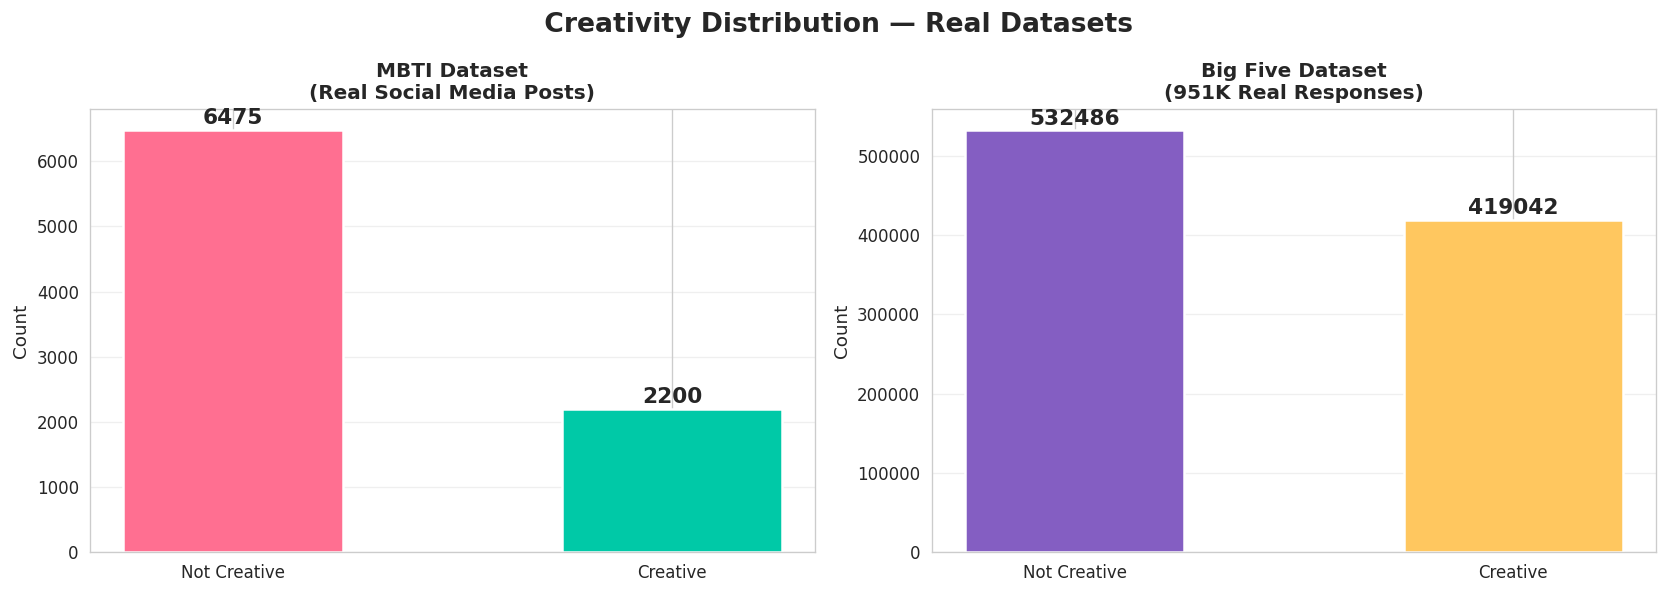

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(' Creativity Distribution — Real Datasets', fontsize=16, fontweight='bold')

counts1 = mbti_features['Is_Creative'].value_counts()
bars1 = axes[0].bar(['Not Creative','Creative'], counts1.values,
                     color=['#FF6F91','#00C9A7'], edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars1, counts1.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[0].set_title('MBTI Dataset\n(Real Social Media Posts)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

counts2 = big5_clean['Is_Creative'].value_counts()
bars2 = axes[1].bar(['Not Creative','Creative'], counts2.values,
                     color=['#845EC2','#FFC75F'], edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars2, counts2.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
                 str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[1].set_title('Big Five Dataset\n(951K Real Responses)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
MBTI Type Creativity Rate
</h2>

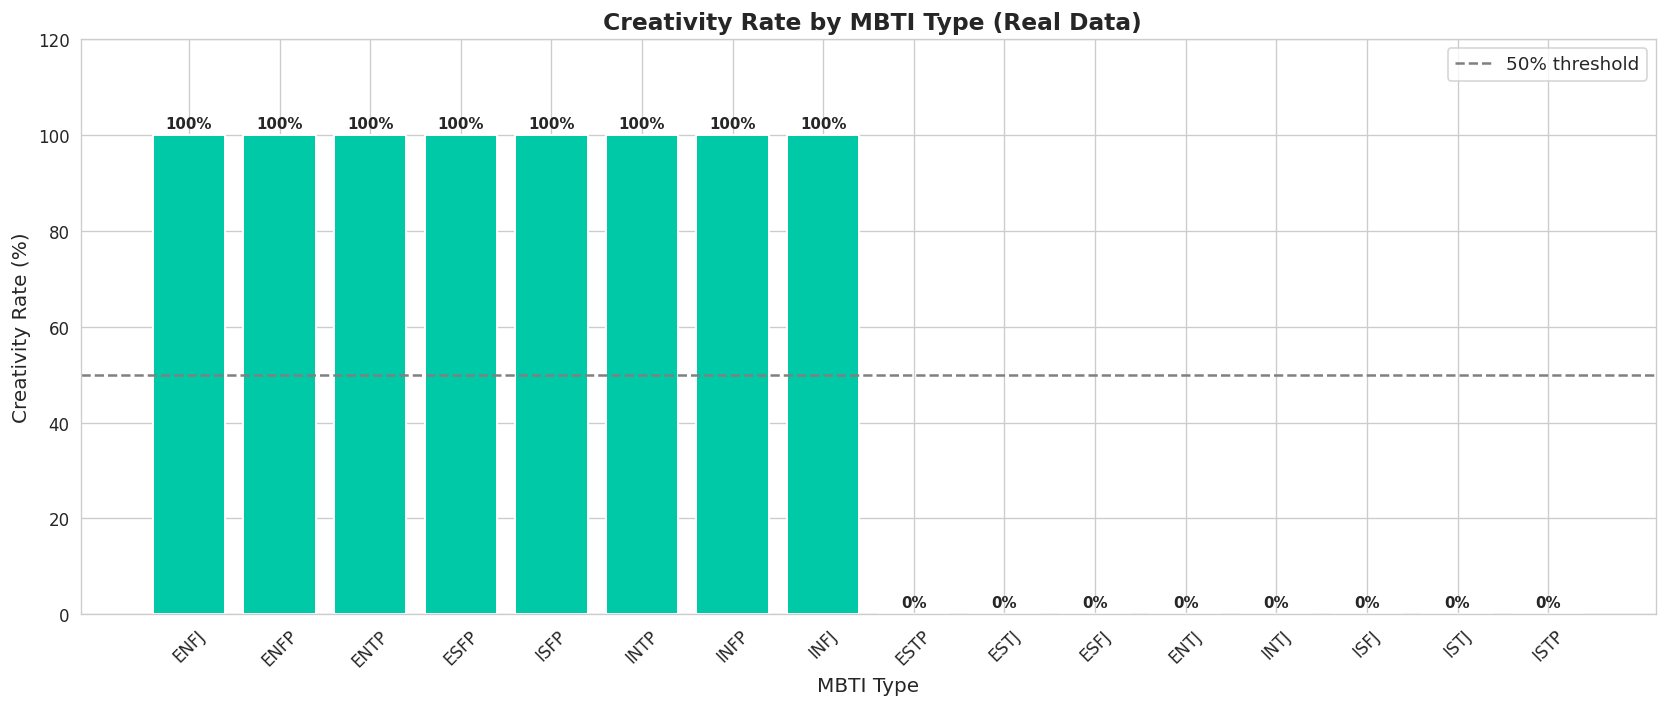

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

type_rate = mbti_features.groupby('type')['Is_Creative'].mean().sort_values(ascending=False)
colors_bar = ['#00C9A7' if v == 1.0 else '#845EC2' if v > 0.5 else '#FF6F91'
              for v in type_rate.values]

bars = ax.bar(type_rate.index, type_rate.values * 100,
              color=colors_bar, edgecolor='white', linewidth=1.2)
ax.axhline(50, color='gray', linestyle='--', lw=1.5, label='50% threshold')

for bar, val in zip(bars, type_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
            f'{val:.0%}', ha='center', fontsize=9, fontweight='bold')

ax.set_title(' Creativity Rate by MBTI Type (Real Data)', fontsize=14, fontweight='bold')
ax.set_xlabel('MBTI Type', fontsize=12)
ax.set_ylabel('Creativity Rate (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
NLP Features Distributions
</h2>

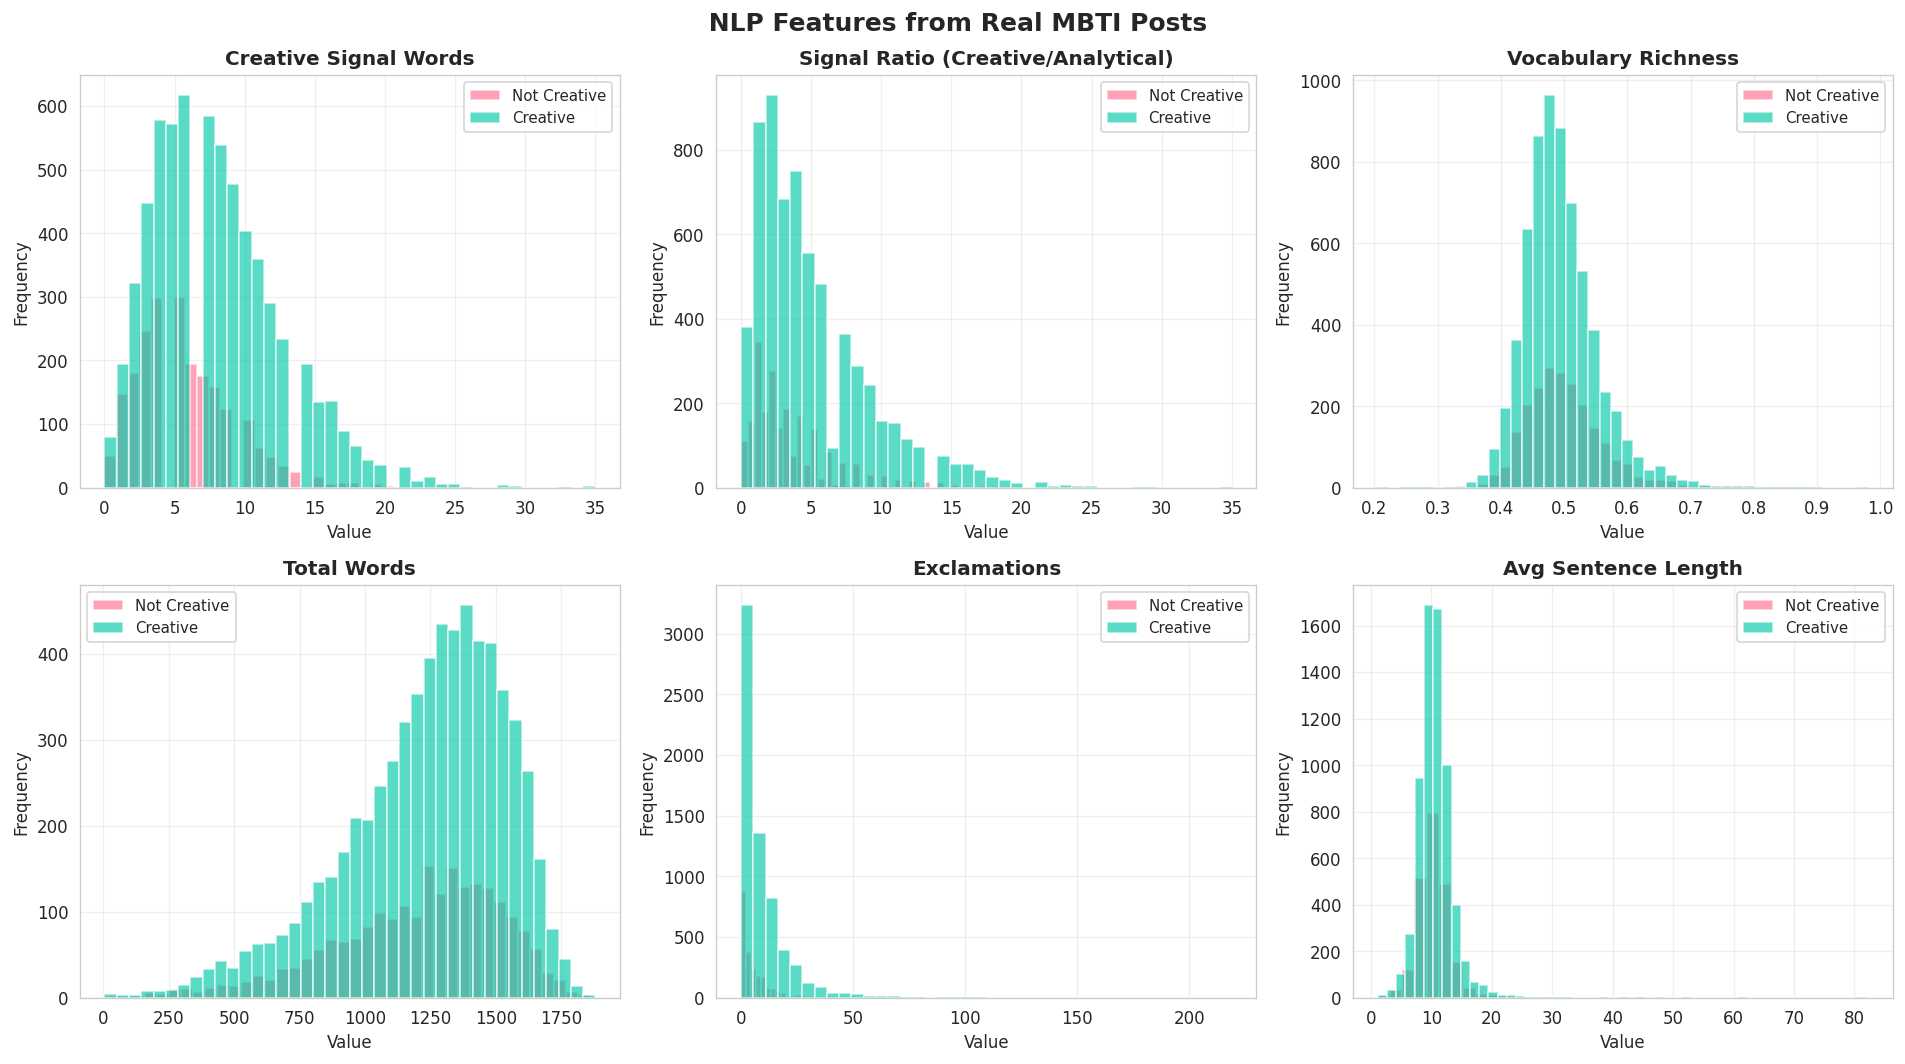

In [7]:
feats_plot  = ['creative_signals','signal_ratio','unique_ratio',
               'total_words','exclamations','avg_sent_length']
titles_plot = ['Creative Signal Words','Signal Ratio (Creative/Analytical)',
               'Vocabulary Richness','Total Words','Exclamations','Avg Sentence Length']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(' NLP Features from Real MBTI Posts', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, (feat, title) in enumerate(zip(feats_plot, titles_plot)):
    for cls, color, lbl in zip([0,1], ['#FF6F91','#00C9A7'],
                                ['Not Creative','Creative']):
        axes[i].hist(mbti_features[mbti_features['Is_Creative']==cls][feat],
                     bins=40, alpha=0.65, color=color, label=lbl, edgecolor='white')
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Correlation Heatmap
</h2>

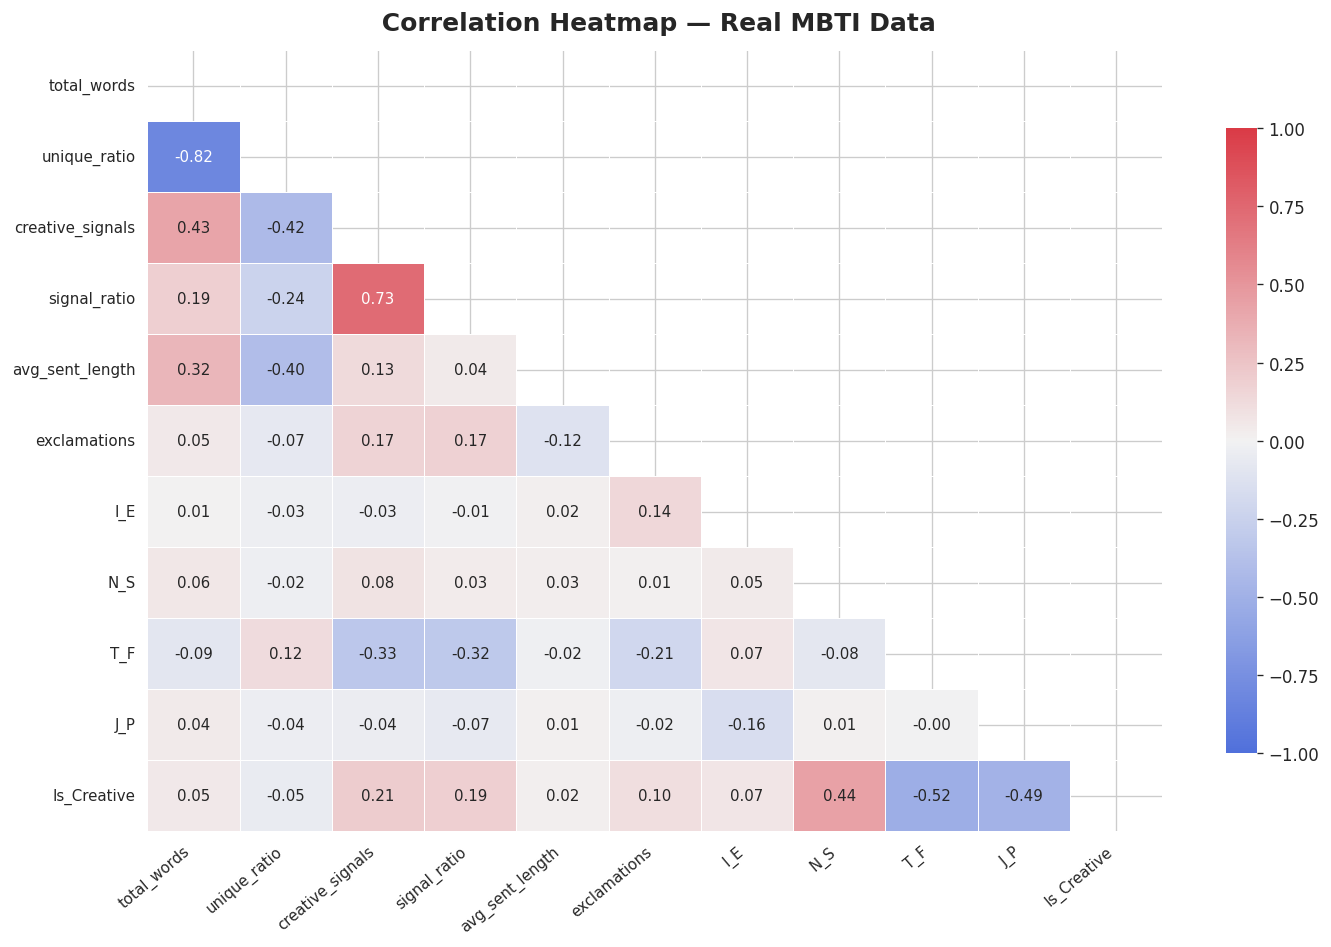

In [8]:
corr_cols = ['total_words','unique_ratio','creative_signals','signal_ratio',
             'avg_sent_length','exclamations','I_E','N_S','T_F','J_P','Is_Creative']

fig, ax = plt.subplots(figsize=(12, 8))
corr = mbti_features[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(260, 10, as_cmap=True)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 9}, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})

ax.set_title(' Correlation Heatmap — Real MBTI Data', fontsize=15, fontweight='bold', pad=12)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Build RAG Knowledge Base
</h2>

In [9]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')
chroma_client = chromadb.Client(Settings(anonymized_telemetry=False))
collection = chroma_client.create_collection(
    name="creativity_profiles",
    metadata={"hnsw:space": "cosine"}
)

CREATIVE_TYPES = ['ENFP','INFP','ENTP','INTP','ENFJ','INFJ','ISFP','ESFP']
creative_samples    = mbti_df[mbti_df['type'].isin(CREATIVE_TYPES)].sample(5, random_state=42)
noncreative_samples = mbti_df[~mbti_df['type'].isin(CREATIVE_TYPES)].sample(5, random_state=42)

kb_samples = pd.concat([creative_samples, noncreative_samples]).reset_index(drop=True)
kb_samples['label'] = [1]*5 + [0]*5
kb_samples['kb_id'] = [f"kb_{i}" for i in range(10)]
kb_samples['text_short'] = kb_samples['posts'].str[:500]

embeddings = embedder.encode(kb_samples['text_short'].tolist()).tolist()

collection.add(
    documents=kb_samples['text_short'].tolist(),
    embeddings=embeddings,
    ids=kb_samples['kb_id'].tolist(),
    metadatas=[{"label": int(r['label']), "mbti_type": r['type']}
               for _, r in kb_samples.iterrows()]
)

print(f" RAG Knowledge Base ready: {collection.count()} real profiles")
print(kb_samples[['type','label']])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

 RAG Knowledge Base ready: 10 real profiles
   type  label
0  INFP      1
1  ENFJ      1
2  INTP      1
3  INFP      1
4  INFP      1
5  INTJ      0
6  INTJ      0
7  ENTJ      0
8  INTJ      0
9  ISFJ      0


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
 NLP features 
</h2>

In [10]:
FEATURES = ['total_words','unique_words','unique_ratio',
            'creative_signals','analytical_signals','signal_ratio',
            'avg_sent_length','exclamations','questions_used','links_count']

X = mbti_features[FEATURES]
y = mbti_features['Is_Creative']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost':              XGBClassifier(n_estimators=200, random_state=42,
                                          use_label_encoder=False, eval_metric='logloss',
                                          verbosity=0),
    'LightGBM':             LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
}

results = {}
for name, model in models.items():
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    results[name] = {
        'Accuracy': round(accuracy_score(y_test, preds)*100, 2),
        'F1 Score': round(f1_score(y_test, preds)*100, 2),
        'ROC-AUC':  round(roc_auc_score(y_test, proba)*100, 2),
        'preds': preds, 'proba': proba
    }
    print(f" {name:25s} → Acc: {results[name]['Accuracy']}%  "
          f"F1: {results[name]['F1 Score']}%  AUC: {results[name]['ROC-AUC']}%")

 Logistic Regression       → Acc: 74.76%  F1: 85.51%  AUC: 65.87%
 Random Forest             → Acc: 73.49%  F1: 84.38%  AUC: 60.32%
 Gradient Boosting         → Acc: 73.95%  F1: 84.84%  AUC: 63.75%
 XGBoost                   → Acc: 70.14%  F1: 81.53%  AUC: 59.52%
 LightGBM                  → Acc: 73.03%  F1: 83.94%  AUC: 61.31%


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
 Model Comparison Chart
</h2>

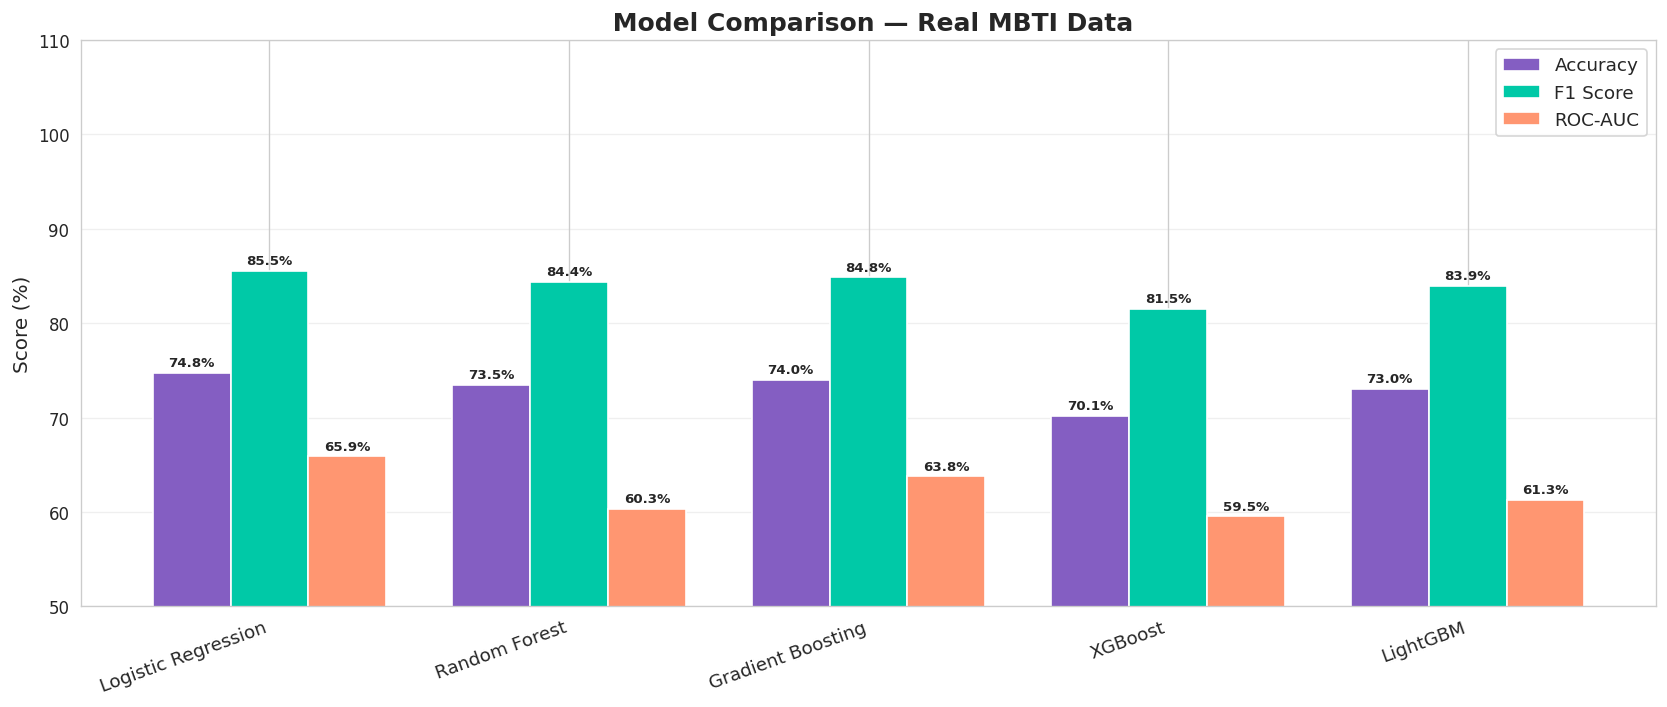

In [11]:
model_names = list(results.keys())
accuracies  = [results[m]['Accuracy']  for m in model_names]
f1_scores   = [results[m]['F1 Score']  for m in model_names]
auc_scores  = [results[m]['ROC-AUC']   for m in model_names]

x, width = np.arange(len(model_names)), 0.26

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x-width, accuracies, width, label='Accuracy',  color='#845EC2', edgecolor='white')
b2 = ax.bar(x,       f1_scores,  width, label='F1 Score',  color='#00C9A7', edgecolor='white')
b3 = ax.bar(x+width, auc_scores, width, label='ROC-AUC',   color='#FF9671', edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f'{bar.get_height():.1f}%', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=11)
ax.set_ylim(50, 110)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title(' Model Comparison — Real MBTI Data', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
ROC Curves
</h2>

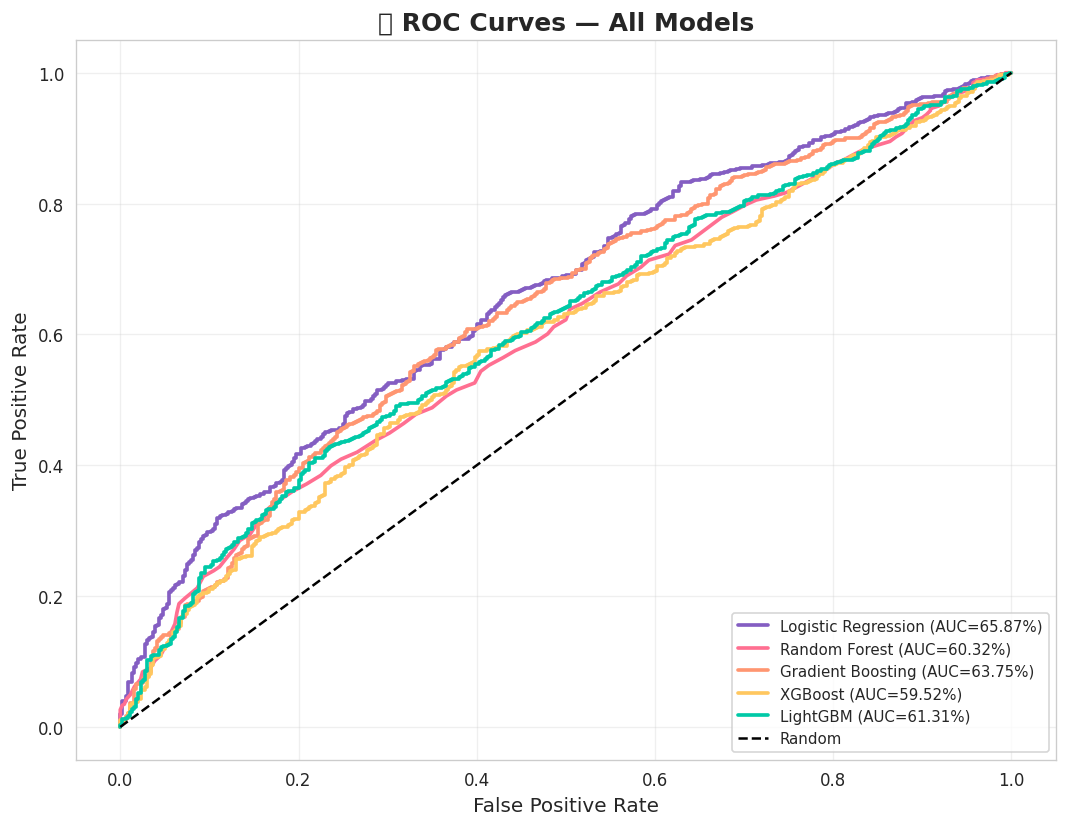

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))
roc_colors = ['#845EC2','#FF6F91','#FF9671','#FFC75F','#00C9A7']

for (name, res), color in zip(results.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, color=color, lw=2.2,
            label=f"{name} (AUC={res['ROC-AUC']}%)")

ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('📉 ROC Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Feature Importance
</h2>

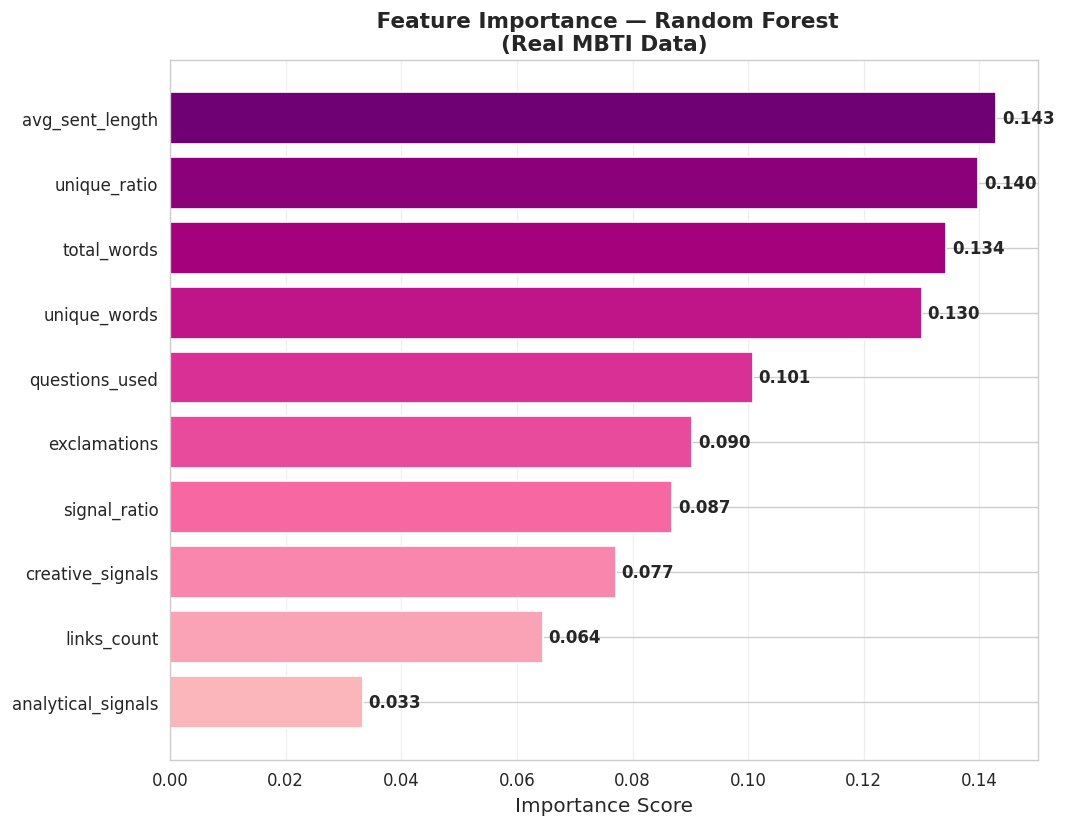

In [13]:
rf  = models['Random Forest']
fi  = pd.DataFrame({'Feature': FEATURES,
                    'Importance': rf.feature_importances_}).sort_values('Importance')

fig, ax = plt.subplots(figsize=(9, 7))
colors_fi = plt.cm.RdPu(np.linspace(0.3, 0.9, len(fi)))
ax.barh(fi['Feature'], fi['Importance'], color=colors_fi, edgecolor='white')

for val, feat in zip(fi['Importance'], fi['Feature']):
    ax.text(val+0.001, list(fi['Feature']).index(feat),
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

ax.set_title(' Feature Importance — Random Forest\n(Real MBTI Data)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:34px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
RAG Function
</h2>

In [14]:
def rag_retrieve(text: str, top_k: int = 3) -> dict:
    query_embed = embedder.encode([text[:500]]).tolist()
    res = collection.query(
        query_embeddings=query_embed,
        n_results=top_k,
        include=['documents','metadatas','distances']
    )
    metas        = res['metadatas'][0]
    distances    = res['distances'][0]
    similarities = [round(1-d, 4) for d in distances]
    labels       = [m['label']     for m in metas]
    types        = [m['mbti_type'] for m in metas]

    c_score = sum(s for s,l in zip(similarities, labels) if l==1)
    a_score = sum(s for s,l in zip(similarities, labels) if l==0)
    rag_label  = 1 if c_score >= a_score else 0
    confidence = round(c_score / (c_score + a_score + 1e-9) * 100, 2)

    return {
        'rag_label':      rag_label,
        'rag_confidence': confidence,
        'top_types':      types,
        'similarities':   similarities
    }

print(" RAG function ready!")

 RAG function ready!


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
 Test on Real Posts
</h2>

In [15]:
best_name = max(results, key=lambda m: results[m]['Accuracy'])
sample_idx   = X_test.sample(5, random_state=7).index
sample_posts = mbti_df.loc[sample_idx, 'posts'].str[:300].values
sample_types = mbti_df.loc[sample_idx, 'type'].values
sample_true  = y_test.loc[sample_idx].values

best_model = models[best_name]
Xsample    = X_test.loc[sample_idx]
Xinput     = scaler.transform(Xsample) if best_name == 'Logistic Regression' else Xsample

ml_preds = best_model.predict(Xinput)
ml_proba = best_model.predict_proba(Xinput)[:,1]

rag_res     = [rag_retrieve(post) for post in sample_posts]
rag_conf    = [r['rag_confidence'] for r in rag_res]

final_scores = [round(0.4*(rc/100) + 0.6*mp, 2)*100
                for rc, mp in zip(rag_conf, ml_proba)]
final_labels = [1 if s >= 50 else 0 for s in final_scores]

results_df = pd.DataFrame({
    'MBTI Type':      sample_types,
    'True Label':     ['🎨 Creative' if l==1 else '🔢 Not Creative' for l in sample_true],
    'Prediction':     ['🎨 Creative' if l==1 else '🔢 Not Creative' for l in final_labels],
    'Confidence (%)': final_scores,
    'ML Score (%)':   (ml_proba * 100).round(1),
    'RAG Score (%)':  rag_conf,
    'Correct?':       ['✅' if p==t else '❌' for p,t in zip(final_labels, sample_true)]
})

def style_pred(v):
    if '🎨' in str(v): return 'background-color:#00C9A7;color:white;font-weight:bold'
    if '🔢' in str(v): return 'background-color:#FF6F91;color:white;font-weight:bold'
    if v == '✅':       return 'background-color:#00C9A7;color:white;font-weight:bold'
    if v == '❌':       return 'background-color:#FF6F91;color:white;font-weight:bold'
    return ''

display(results_df.style
    .applymap(style_pred, subset=['True Label','Prediction','Correct?'])
    .background_gradient(cmap='RdPu', subset=['Confidence (%)'])
    .background_gradient(cmap='Blues', subset=['ML Score (%)','RAG Score (%)'])
    .set_caption("🎯 Real Post Predictions - NLP + RAG Pipeline")
    .set_table_styles([
        {'selector':'caption',
         'props':[('font-size','16px'),('font-weight','bold'),('color','#845EC2')]},
        {'selector':'th',
         'props':[('background-color','#845EC2'),('color','white'),
                  ('font-size','12px'),('text-align','center'),('padding','8px')]},
        {'selector':'td',
         'props':[('text-align','center'),('font-size','12px'),('padding','7px')]}
    ]))

,MBTI Type,True Label,Prediction,Confidence (%),ML Score (%),RAG Score (%),Correct?
0,ENTP,🎨 Creative,🎨 Creative,73.000000,79.800000,61.840000,✅
1,ENFP,🎨 Creative,🎨 Creative,84.000000,93.400000,69.870000,✅
2,ISFP,🎨 Creative,🎨 Creative,52.000000,67.700000,29.290000,✅
3,ISFJ,🔢 Not Creative,🎨 Creative,71.000000,93.700000,36.060000,❌
4,INTJ,🔢 Not Creative,🔢 Not Creative,36.000000,59.600000,0.000000,✅


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
 Leaderboard
</h2>

In [16]:
final_df = pd.DataFrame({
    'Model':    list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results],
    'F1 Score': [results[m]['F1 Score'] for m in results],
    'ROC-AUC':  [results[m]['ROC-AUC']  for m in results],
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)
final_df.index += 1

def color_score(val):
    if not isinstance(val, float): return ''
    if val >= 80: return 'background-color:#00C9A7;color:white;font-weight:bold'
    if val >= 70: return 'background-color:#FFC75F;color:black;font-weight:bold'
    return       'background-color:#FF6F91;color:white;font-weight:bold'

display(final_df.style
    .applymap(color_score, subset=['Accuracy','F1 Score','ROC-AUC'])
    .set_caption("🏅 Final Model Leaderboard — Real Data")
    .set_table_styles([
        {'selector':'caption',
         'props':[('font-size','16px'),('font-weight','bold'),('color','#845EC2')]},
        {'selector':'th',
         'props':[('background-color','#845EC2'),('color','white'),
                  ('font-size','13px'),('text-align','center'),('padding','8px')]},
        {'selector':'td',
         'props':[('text-align','center'),('font-size','13px'),('padding','7px')]}
    ]))

,Model,Accuracy,F1 Score,ROC-AUC
1,Logistic Regression,74.760000,85.510000,65.870000
2,Gradient Boosting,73.950000,84.840000,63.750000
3,Random Forest,73.490000,84.380000,60.320000
4,LightGBM,73.030000,83.940000,61.310000
5,XGBoost,70.140000,81.530000,59.520000


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Test on Real Text Examples
</h2>

In [17]:
def predict_from_text(text: str, person_name: str = "Person") -> dict:
   
    text_lower = text.lower()
    words      = text_lower.split()
    sentences  = re.split(r'[.!?]+', text_lower)

    creative_words   = ['imagine','dream','create','invent','design','explore',
                        'original','unique','art','music','write','paint','idea',
                        'innovate','experiment','vision','inspire','emotion','feel',
                        'fantasy','curious','wonder','novel','unusual','love','beautiful']
    analytical_words = ['data','logic','process','method','system','rule',
                        'procedure','fact','measure','plan','structured','precise',
                        'consistent','efficient','technical','analysis','calculate']

    creative_count   = sum(1 for w in words if w in creative_words)
    analytical_count = sum(1 for w in words if w in analytical_words)
    avg_sent_len     = np.mean([len(s.split()) for s in sentences if s.strip()]) if sentences else 0
    unique_ratio     = len(set(words)) / (len(words) + 1)

    feat_vector = pd.DataFrame([{
        'total_words':        len(words),
        'unique_words':       len(set(words)),
        'unique_ratio':       round(unique_ratio, 4),
        'creative_signals':   creative_count,
        'analytical_signals': analytical_count,
        'signal_ratio':       round(creative_count / (analytical_count + 1), 4),
        'avg_sent_length':    round(avg_sent_len, 2),
        'exclamations':       text.count('!'),
        'questions_used':     text.count('?'),
        'links_count':        len(re.findall(r'http\S+', text)),
    }])

    rag_res    = rag_retrieve(text)
    rag_conf   = rag_res['rag_confidence']

    best_model = models[best_name]
    if best_name == 'Logistic Regression':
        ml_proba = best_model.predict_proba(scaler.transform(feat_vector))[0][1]
    else:
        ml_proba = best_model.predict_proba(feat_vector)[0][1]

    final_score = round((0.4 * rag_conf/100 + 0.6 * ml_proba) * 100, 1)
    final_label = 1 if final_score >= 50 else 0
    verdict     = "🎨 CREATIVE" if final_label == 1 else "🔢 NOT CREATIVE"

    return {
        'name':          person_name,
        'verdict':       verdict,
        'confidence':    final_score,
        'ml_score':      round(ml_proba * 100, 1),
        'rag_score':     rag_conf,
        'creative_words': creative_count,
        'unique_ratio':  round(unique_ratio * 100, 1),
    }


examples = [
    ("Sara - The Artist",
     """I love spending my evenings painting and writing poetry. 
     My mind is always wandering to new ideas and imagining fantastical worlds. 
     I feel deeply inspired by music and nature. 
     I enjoy experimenting with new art styles and I get bored with routine quickly. 
     Creating something original gives me so much joy and emotion!"""),

    ("Nada - The Engineer",
     """I work with data and systems every day. 
     I follow structured procedures and logical analysis to solve problems. 
     I prefer proven technical methods over experimental approaches. 
     My work involves precise calculations and efficient processes. 
     I rarely daydream - I focus on facts and measurable outcomes."""),

    ("Layla - The Mixed",
     """I enjoy reading books and occasionally writing short stories. 
     At work I analyze data but I also like designing presentations creatively. 
     Sometimes I imagine new ideas but I also rely on logic and planning. 
     I have a few hobbies like cooking new recipes and listening to music."""),

    ("Omar - The Innovator",
     """I am always curious about how things work and love to explore new concepts. 
     I invented a small device last year just for fun! 
     I wonder about the universe and write down my thoughts and visions daily. 
     Art and music are my escape — they inspire my best ideas. 
     I dream of creating something that changes the world!"""),

    ("Nour - The Analyst",
     """My job requires careful analysis and following established procedures. 
     I create detailed plans and track progress with precise metrics. 
     I prefer consistency and reliability in everything I do. 
     Logic and data guide all my decisions. 
     I find comfort in structured environments with clear rules."""),
]

all_preds = [predict_from_text(text, name) for name, text in examples]

pred_df = pd.DataFrame({
    'Person':          [p['name']          for p in all_preds],
    'Verdict':         [p['verdict']       for p in all_preds],
    'Confidence (%)':  [p['confidence']    for p in all_preds],
    'ML Score (%)':    [p['ml_score']      for p in all_preds],
    'RAG Score (%)':   [p['rag_score']     for p in all_preds],
    'Creative Words':  [p['creative_words'] for p in all_preds],
    'Vocab Richness (%)': [p['unique_ratio'] for p in all_preds],
})

def style_table(v):
    if '🎨' in str(v): return 'background-color:#00C9A7;color:white;font-weight:bold'
    if '🔢' in str(v): return 'background-color:#FF6F91;color:white;font-weight:bold'
    return ''

display(pred_df.style
    .applymap(style_table, subset=['Verdict'])
    .background_gradient(cmap='RdPu',  subset=['Confidence (%)'])
    .background_gradient(cmap='Blues', subset=['ML Score (%)','RAG Score (%)'])
    .background_gradient(cmap='Greens',subset=['Creative Words','Vocab Richness (%)'])
    .set_caption("🎨 Creativity Predictions from Real Text Input")
    .set_table_styles([
        {'selector':'caption',
         'props':[('font-size','17px'),('font-weight','bold'),('color','#845EC2'),
                  ('margin-bottom','12px')]},
        {'selector':'th',
         'props':[('background-color','#845EC2'),('color','white'),
                  ('font-size','13px'),('text-align','center'),('padding','10px')]},
        {'selector':'td',
         'props':[('text-align','center'),('font-size','12px'),('padding','8px')]}
    ]))

,Person,Verdict,Confidence (%),ML Score (%),RAG Score (%),Creative Words,Vocab Richness (%)
0,Sara - The Artist,🎨 CREATIVE,84.800000,74.700000,100.000000,5,79.600000
1,Nada - The Engineer,🔢 NOT CREATIVE,41.200000,46.000000,33.990000,0,80.400000
2,Layla - The Mixed,🎨 CREATIVE,50.100000,58.600000,37.290000,1,75.000000
3,Omar - The Innovator,🎨 CREATIVE,78.700000,84.800000,69.460000,9,81.400000
4,Nour - The Analyst,🔢 NOT CREATIVE,41.600000,50.700000,27.920000,1,77.800000


<h2 style="
text-align:center;
color:#1a237e;
font-weight:bold;
font-size:32px;
text-shadow:2px 2px 8px rgba(26,35,126,0.4);
letter-spacing:1px;">
Visual Confidence Chart
</h2>

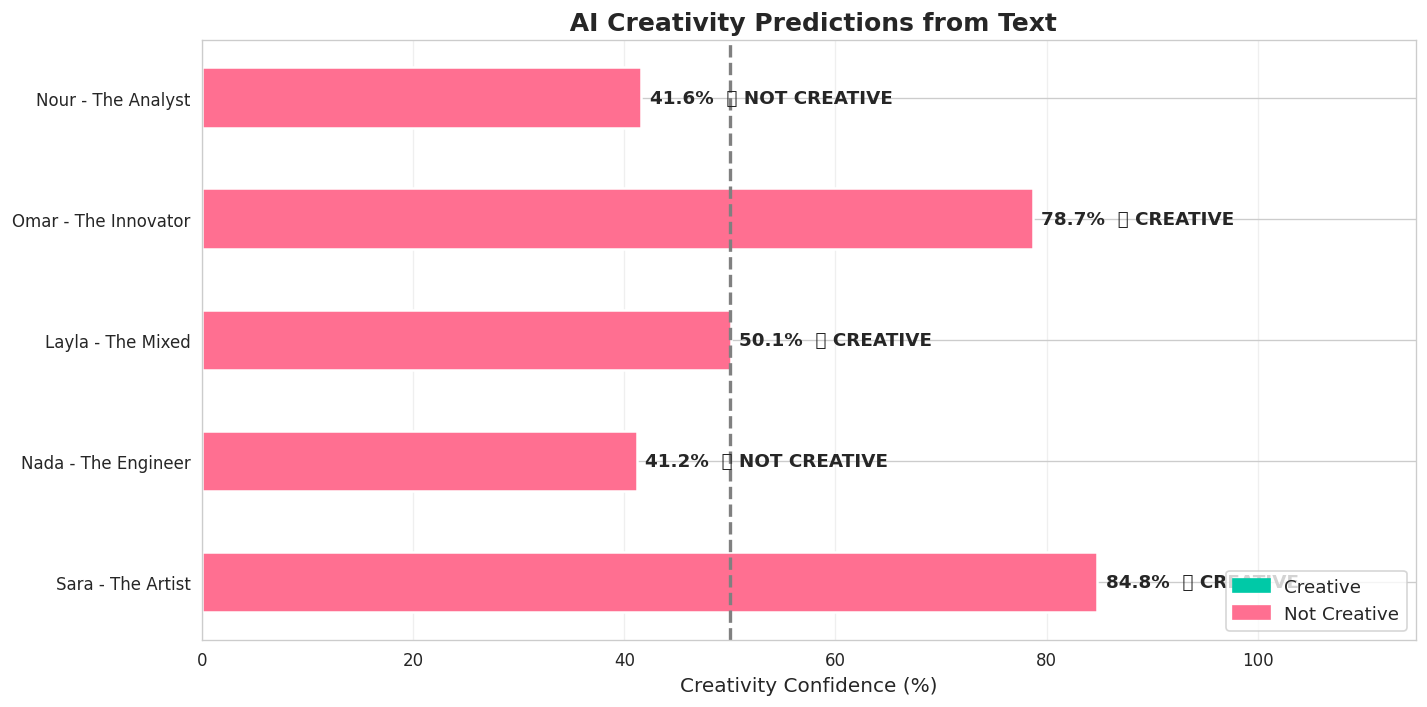

In [18]:
names       = [p['name'].split('—')[0].strip() for p in all_preds]
confidences = [p['confidence'] for p in all_preds]
colors_bar  = ['#00C9A7' if p['verdict'] == ' CREATIVE'
               else '#FF6F91' for p in all_preds]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(names, confidences, color=colors_bar,
               edgecolor='white', linewidth=1.5, height=0.5)

ax.axvline(50, color='gray', linestyle='--', lw=2, label='Decision Boundary (50%)')

for bar, val, pred in zip(bars, confidences, all_preds):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
            f"{val}%  {pred['verdict']}",
            va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 115)
ax.set_xlabel('Creativity Confidence (%)', fontsize=12)
ax.set_title(' AI Creativity Predictions from Text', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)

creative_patch    = plt.Rectangle((0,0),1,1, color='#00C9A7', label='Creative')
noncreative_patch = plt.Rectangle((0,0),1,1, color='#FF6F91', label='Not Creative')
ax.legend(handles=[creative_patch, noncreative_patch], fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()